Dataset loaded successfully.

First 5 rows:
   eruptions  waiting
0      3.600       79
1      1.800       54
2      3.333       74
3      2.283       62
4      4.533       85

Dataset Shape: (272, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   eruptions  272 non-null    float64
 1   waiting    272 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 4.4 KB

Missing Values:
eruptions    0
waiting      0
dtype: int64

Descriptive Statistics:
        eruptions     waiting
count  272.000000  272.000000
mean     3.487783   70.897059
std      1.141371   13.594974
min      1.600000   43.000000
25%      2.162750   58.000000
50%      4.000000   76.000000
75%      4.454250   82.000000
max      5.100000   96.000000


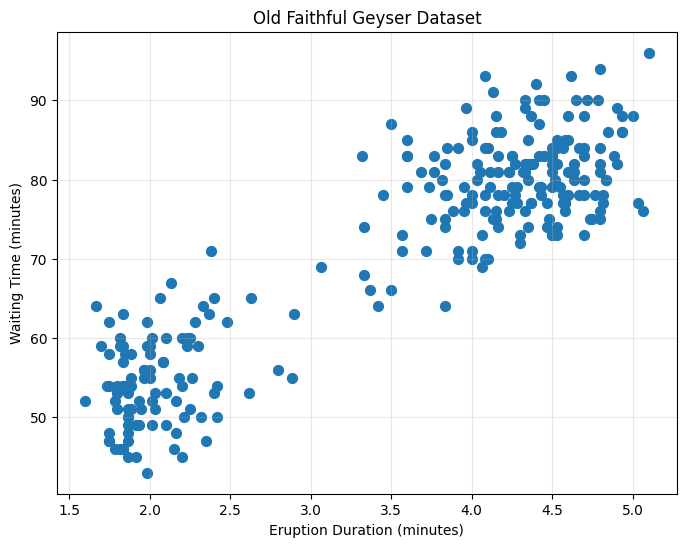


Standardized data:
[[ 0.09849886  0.59712344]
 [-1.48145856 -1.24518118]
 [-0.13586149  0.22866251]
 [-1.05750332 -0.6556437 ]
 [ 0.91744345  1.03927655]]

K-Means clustering completed successfully.

Cluster Centers:
   eruptions    waiting
0   4.296328  80.080460
1   2.052204  54.591837

Number of observations in each cluster:
Cluster
0    174
1     98
Name: count, dtype: int64


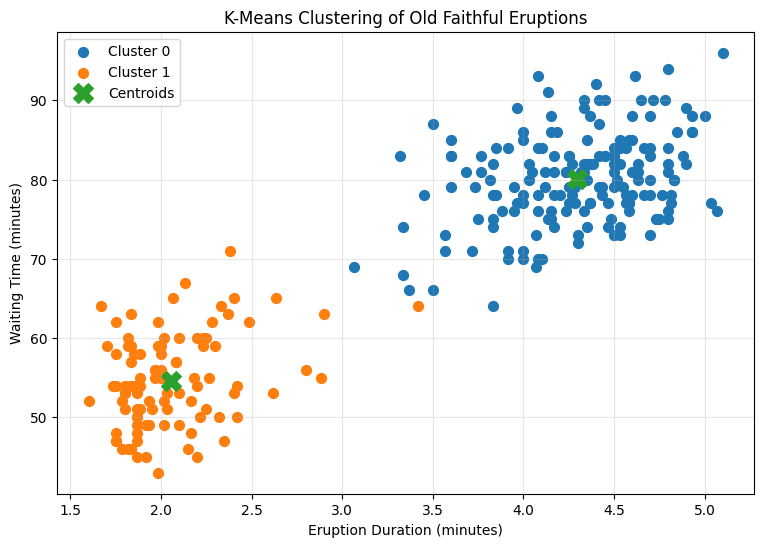


Silhouette Score: 0.7451774401188772

Average Eruption Duration and Waiting Time by Cluster:
         eruptions    waiting
Cluster                      
0         4.296328  80.080460
1         2.052204  54.591837


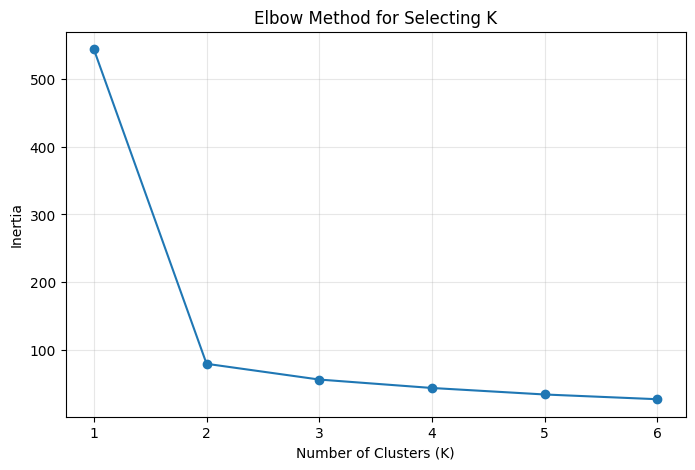


Final Dataset with Cluster Labels:
   eruptions  waiting  Cluster
0      3.600       79        0
1      1.800       54        1
2      3.333       74        0
3      2.283       62        1
4      4.533       85        0
5      2.883       55        1
6      4.700       88        0
7      3.600       85        0
8      1.950       51        1
9      4.350       85        0

K-Means clustering was successfully applied to the Old Faithful
geyser dataset using eruption duration and waiting time.
The data was standardized before clustering.
Two clusters were created using K-Means.
The clusters represent different eruption patterns based on
eruption duration and waiting time.
The clusters and their centroids were visualized, and the
silhouette score was calculated to evaluate the clustering.


In [1]:
# 1. Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


# 2. Load the Old Faithful dataset

url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/faithful.csv"

df = pd.read_csv(url)

df = df[['eruptions', 'waiting']]

print("Dataset loaded successfully.")
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:", df.shape)


# 3. Check dataset information

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())


# 4. Visualize the original dataset

plt.figure(figsize=(8, 6))

plt.scatter(
    df['eruptions'],
    df['waiting'],
    s=50
)

plt.xlabel("Eruption Duration (minutes)")
plt.ylabel("Waiting Time (minutes)")
plt.title("Old Faithful Geyser Dataset")
plt.grid(True, alpha=0.3)

plt.show()


# 5. Prepare the data for clustering

X = df[['eruptions', 'waiting']]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nStandardized data:")
print(X_scaled[:5])


# 6. Apply K-Means clustering

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("\nK-Means clustering completed successfully.")


# 7. Display cluster centers

centers_scaled = kmeans.cluster_centers_

centers_original = scaler.inverse_transform(
    centers_scaled
)

centers_df = pd.DataFrame(
    centers_original,
    columns=['eruptions', 'waiting']
)

print("\nCluster Centers:")
print(centers_df)


# 8. Display number of observations in each cluster

print("\nNumber of observations in each cluster:")
print(df['Cluster'].value_counts().sort_index())


# 9. Visualize the K-Means clusters

plt.figure(figsize=(9, 6))

for cluster in sorted(df['Cluster'].unique()):

    cluster_data = df[df['Cluster'] == cluster]

    plt.scatter(
        cluster_data['eruptions'],
        cluster_data['waiting'],
        s=50,
        label=f'Cluster {cluster}'
    )

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    s=200,
    marker='X',
    label='Centroids'
)

plt.xlabel("Eruption Duration (minutes)")
plt.ylabel("Waiting Time (minutes)")
plt.title("K-Means Clustering of Old Faithful Eruptions")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


# 10. Calculate silhouette score

silhouette = silhouette_score(
    X_scaled,
    clusters
)

print("\nSilhouette Score:", silhouette)


# 11. Analyze the clusters

cluster_summary = df.groupby('Cluster')[
    ['eruptions', 'waiting']
].mean()

print("\nAverage Eruption Duration and Waiting Time by Cluster:")
print(cluster_summary)


# 12. Compare different values of K

inertia = []
k_values = range(1, 7)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Selecting K")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)

plt.show()


# 13. Display the final clustered dataset

print("\nFinal Dataset with Cluster Labels:")
print(df.head(10))


# 14. Conclusion

print("\nK-Means clustering was successfully applied to the Old Faithful")
print("geyser dataset using eruption duration and waiting time.")
print("The data was standardized before clustering.")
print("Two clusters were created using K-Means.")
print("The clusters represent different eruption patterns based on")
print("eruption duration and waiting time.")
print("The clusters and their centroids were visualized, and the")
print("silhouette score was calculated to evaluate the clustering.")